# Hei Njål
# ***I LOVE COCK***

In [134]:
print('U lost bbygurl?')

U lost bbygurl?


Importing our dataset

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("../data/england-premier-league-matches-2018-to-2019-stats.csv")

Analyszing features

In [136]:
df.head()

odds_columns = [col for col in df.columns if 'odds' in col.lower()]
df[odds_columns].sample()
prematch_columns = [col for col in df.columns if 'pre' in col.lower() and 'match' in col.lower()]
df[prematch_columns].sample()
null_columns = [col for col in df.columns if (df[col] == 0).all()]
df[null_columns].head()
not_completed = [col for col in df.columns if (df['status'] != 'complete').any()]
print(not_completed)


[]


Data cleaning

In [137]:

#Remove all columns in the dataset that include odds. 
df_filtered = df.drop(columns = odds_columns)

#The first match 2 matches of the season has no 'pre-match' content, but are valued at 0, which could mess with this feature
df_filtered.loc[df['Game Week'] <= 2, prematch_columns] = np.nan


df_filtered.sample(5)

,timestamp,date_GMT,status,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),...,over_25_percentage_pre_match,over_35_percentage_pre_match,over_45_percentage_pre_match,over_15_HT_FHG_percentage_pre_match,over_05_HT_FHG_percentage_pre_match,over_15_2HG_percentage_pre_match,over_05_2HG_percentage_pre_match,average_corners_per_match_pre_match,average_cards_per_match_pre_match,stadium_name
237,1548877500,Jan 30 2019 - 7:45pm,complete,28339,Southampton,Crystal Palace,Andre Marriner,24,1.00,1.08,...,66.0,39.0,17.0,22.0,61.0,61.0,74.0,9.02,4.72,St. Mary's Stadium (Southampton- Hampshire)
353,1556373600,Apr 27 2019 - 2:00pm,complete,23822,Fulham,Cardiff City,Chris Kavanagh,36,1.06,0.65,...,47.0,24.0,21.0,33.0,71.0,44.0,77.0,9.12,3.94,Craven Cottage (London)
201,1546354800,Jan 01 2019 - 3:00pm,complete,59887,Arsenal,Fulham,Graham Scott,21,2.30,0.20,...,50.0,40.0,15.0,30.0,70.0,60.0,90.0,8.60,4.00,Emirates Stadium (London)
25,1535214600,Aug 25 2018 - 4:30pm,complete,53294,Liverpool,Brighton & Hove Albion,Chris Kavanagh,3,3.00,0.00,...,50.0,50.0,0.0,50.0,100.0,50.0,100.0,7.00,3.00,Anfield (Liverpool)
67,1538238600,Sep 29 2018 - 4:30pm,complete,40625,Chelsea,Liverpool,Andre Marriner,7,3.00,3.00,...,67.0,34.0,34.0,50.0,84.0,50.0,100.0,10.67,1.67,Stamford Bridge (London)


Feature Importance Testing

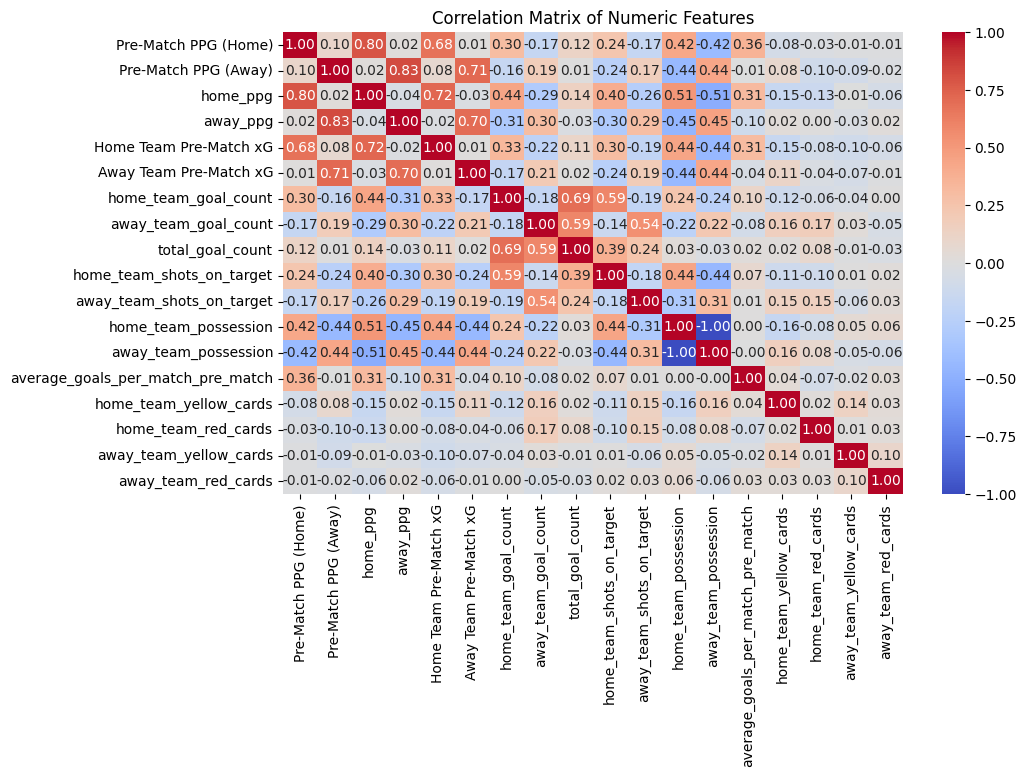

In [156]:
correlation_matrix = df_final.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Final Feature Selection

In [155]:
selected_features = [
    #'Game Week',
    #'home_team_name',
    #'away_team_name',
    'Pre-Match PPG (Home)',
    'Pre-Match PPG (Away)',
    'home_ppg',
    'away_ppg',
    'Home Team Pre-Match xG',
    'Away Team Pre-Match xG',
    'home_team_goal_count',
    'away_team_goal_count',
    'total_goal_count',
    'home_team_shots_on_target',
    'away_team_shots_on_target',
    'home_team_possession',
    'away_team_possession',
    'average_goals_per_match_pre_match',
    'home_team_yellow_cards',
    'home_team_red_cards',
    'away_team_yellow_cards',
    'away_team_red_cards'
]


df_final = df_filtered[selected_features]

df_final.sample(10)

,Pre-Match PPG (Home),Pre-Match PPG (Away),home_ppg,away_ppg,Home Team Pre-Match xG,Away Team Pre-Match xG,home_team_goal_count,away_team_goal_count,total_goal_count,home_team_shots_on_target,away_team_shots_on_target,home_team_possession,away_team_possession,average_goals_per_match_pre_match,home_team_yellow_cards,home_team_red_cards,away_team_yellow_cards,away_team_red_cards
373,1.17,0.94,1.11,1.05,1.47,1.00,0,4,4,3,7,68,32,2.53,1,0,0,0
28,0.00,3.00,1.32,1.58,1.18,1.17,1,2,3,3,4,18,82,3.00,3,0,1,0
370,1.28,2.28,1.21,2.32,1.25,1.70,1,4,5,3,10,23,77,2.39,0,0,0,0
281,1.46,0.46,1.21,0.37,1.25,1.13,1,0,1,5,5,52,48,2.58,2,0,2,0
285,1.50,0.92,1.63,1.05,1.53,1.02,2,0,2,5,3,55,45,2.47,3,0,4,0
336,2.82,1.94,2.84,1.74,2.28,1.40,1,0,1,5,5,60,40,3.56,1,0,2,0
158,0.75,1.14,1.32,1.21,1.25,1.59,1,2,3,5,7,50,50,2.05,2,1,5,0
318,2.81,0.57,2.84,0.74,2.23,1.10,2,0,2,12,2,78,22,3.28,0,0,3,0
139,2.67,1.00,2.79,1.05,1.80,1.36,1,0,1,4,4,57,43,2.59,3,0,2,0
257,1.58,0.77,1.21,0.89,1.20,0.97,1,3,4,7,6,68,32,2.47,1,0,1,0


Defining the Model

In [147]:
Y = df_final[['home_team_goal_count', 'away_team_goal_count']]
X = df_final.drop(columns = ['home_team_goal_count', 'away_team_goal_count'])

Training the model

Evaluating The model

Keep track of changes/adjustments. What didnt work? Why didnt it work? How was it changed?

Data cleaning:
At first all features containing pre-match info were removed, however this can be very valuable and was changed to only 'Nan' the early and not representative values.

Feature selection: 
Feature selection is an iterative process, at the beginning all features thought to be useful were included. Random forrest models are used with feature importance. 

Evaluation: 
The evaluation can both look at how well the model predicts the amount of goals scored by home and away team, but also how often it predicts the coorect outcome of the game (HAD)
